In [1]:
from csv import DictReader

with open('properties_master.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    rows = [r for r in reader]
csv_file.close()

compounds = []
for r in rows:
    if r['properties.flash_point.value'] != '-':
        compounds.append(r)

In [2]:
from sklearn.model_selection import train_test_split

smiles = [c['canonical_smiles'] for c in compounds]
targets = [[float(c['properties.flash_point.value'])] for c in compounds]

smiles_train, smiles_test, targets_train, targets_test = train_test_split(
    smiles, targets, test_size=0.2, random_state=24
)

In [3]:
from ecnet.datasets import QSPRDataset

ds_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
ds_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [4]:
from ecnet.tasks import select_rfr

desc_idx, desc_imp = select_rfr(ds_train, total_importance=0.99, n_estimators=50, n_jobs=4)
ds_train.set_desc_index(desc_idx)
ds_test.set_desc_index(desc_idx)
print(ds_train.desc_names[:5], desc_imp[:5])
with open('fp_desc.txt', 'w') as txt_file:
    txt_file.writelines([str(i) + '\n' for i in desc_idx])
txt_file.close()

['SpAD_B(s)', 'SpAbs_B(s)', 'HyWi_B(s)', 'GMTIV', 'Wi_B(s)'] [0.46893507999539447, 0.054285757978318736, 0.0320731748400333, 0.03164576318580264, 0.019867144079186442]


In [5]:
from ecnet import ECNet

net = ECNet(ds_train.desc_vals.shape[1], ds_train.target_vals.shape[1], 128, 1)
loss_train, loss_valid = net.fit(
    dataset=ds_train,
    batch_size=8,
    epochs=512,
    valid_size=0.2,
    random_state=24,
    lr=0.001,
    patience=64,
    verbose=10
)

Epoch: 0 | Train loss: 2291.128030788679 | Valid loss: 9223372036854775807
Epoch: 10 | Train loss: 353.28650454655747 | Valid loss: 560.1624145507812
Epoch: 20 | Train loss: 263.50388453196894 | Valid loss: 507.73565673828125
Epoch: 30 | Train loss: 278.6964346294754 | Valid loss: 464.71282958984375
Epoch: 40 | Train loss: 187.33868997960002 | Valid loss: 353.4144287109375
Epoch: 50 | Train loss: 138.89816583738735 | Valid loss: 367.2608337402344
Epoch: 60 | Train loss: 128.9782805764602 | Valid loss: 364.8575134277344
Epoch: 70 | Train loss: 129.4505017988521 | Valid loss: 386.1208801269531
Epoch: 80 | Train loss: 115.23307966454628 | Valid loss: 370.6203918457031
Epoch: 90 | Train loss: 108.53778385092144 | Valid loss: 369.85595703125
Epoch: 100 | Train loss: 107.4985810730355 | Valid loss: 362.2040710449219
Epoch: 110 | Train loss: 95.53358478195096 | Valid loss: 341.9919128417969
Epoch: 120 | Train loss: 82.55180777508788 | Valid loss: 373.8738098144531
Epoch: 130 | Train loss: 146

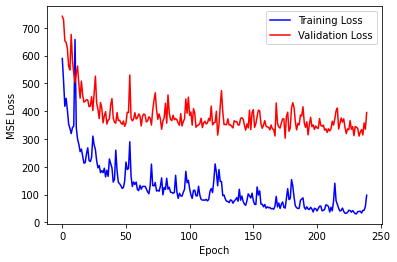

In [6]:
from matplotlib import pyplot as plt

loss_train = loss_train[5:]
loss_valid = loss_valid[5:]
epochs = [i for i in range(len(loss_train))]

plt.clf()
plt.plot(epochs, loss_train, label='Training Loss', color='blue')
plt.plot(epochs, loss_valid, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(loc='upper right')
plt.show()

In [7]:
from sklearn.metrics import median_absolute_error, r2_score

results_train = net.forward(ds_train.desc_vals).detach().numpy()
targets_train = ds_train.target_vals.detach().numpy()
results_test = net.forward(ds_test.desc_vals).detach().numpy()
targets_test = ds_test.target_vals.detach().numpy()

mae_train = median_absolute_error(targets_train, results_train)
mae_test = median_absolute_error(targets_test, results_test)
r2_train = r2_score(targets_train, results_train)
r2_test = r2_score(targets_test, results_test)

print(f'Train: {mae_train}, {r2_train}')
print(f'Test: {mae_test}, {r2_test}')

Train: 4.312406539916992, 0.9549122696887495
Test: 7.064971923828125, 0.8849773954657214


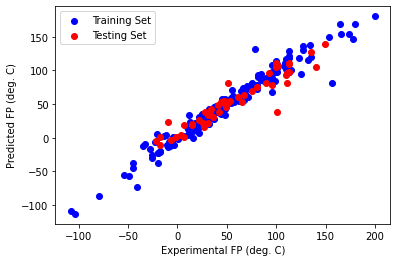

In [8]:
plt.clf()

plt.scatter(targets_train, results_train, label='Training Set', color='blue')
plt.scatter(targets_test, results_test, label='Testing Set', color='red')
plt.legend(loc='upper left')
plt.xlabel('Experimental FP (deg. C)')
plt.ylabel('Predicted FP (deg. C)')
plt.show()

In [9]:
net.save('fp.pt')